<a href="https://colab.research.google.com/github/zxn-999/BSE_CNN/blob/main/CNN_Unet_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import torch
print(torch.__version__)
print(torch.cuda.is_available())

2.10.0+cu128
True


In [8]:
import os
import cv2
import torch
from torch.utils.data import Dataset
import numpy as np

class BSEPatchDataset(Dataset):
    def __init__(self, image_dir, mask_dir, patch_size=256):
        self.image_dir = image_dir
        self.mask_dir = mask_dir
        self.patch_size = patch_size

        self.image_files = sorted([
            f for f in os.listdir(image_dir)
            if f.endswith(".tif")
        ])

        self.patches = []
        self._prepare_patches()

    def _prepare_patches(self):
        for img_name in self.image_files:
            img_path = os.path.join(self.image_dir, img_name)
            mask_path = os.path.join(
                self.mask_dir,
                img_name.replace(".tif", "_mask.tif")
            )

            image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            h, w = image.shape

            for y in range(0, h - self.patch_size + 1, self.patch_size):
                for x in range(0, w - self.patch_size + 1, self.patch_size):
                    self.patches.append((
                        img_path,
                        mask_path,
                        x, y
                    ))

    def __len__(self):
        return len(self.patches)

    def __getitem__(self, idx):
        img_path, mask_path, x, y = self.patches[idx]

        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        image = image[y:y+self.patch_size, x:x+self.patch_size]
        mask = mask[y:y+self.patch_size, x:x+self.patch_size]

        image = torch.from_numpy(image).float().unsqueeze(0) / 255.0
        mask = torch.from_numpy(mask).long()

        # Debug print before clamping
        # print(f"Before clamp - Image: {img_path}, Mask: {mask_path}, Patch_x: {x}, Patch_y: {y}, Mask max: {mask.max().item()}")

        # Clip mask values to ensure they are within [0, 3] for 4 classes
        mask = torch.clamp(mask, min=0, max=3)

        # Debug print after clamping
        # print(f"After clamp - Image: {img_path}, Mask: {mask_path}, Patch_x: {x}, Patch_y: {y}, Mask max: {mask.max().item()}")

        # safety check
        assert mask.max()<=3

        return image, mask

In [11]:
dataset = BSEPatchDataset(
    image_dir="/content/drive/MyDrive/BSE_CNN/dataset/train/img",
    mask_dir="/content/drive/MyDrive/BSE_CNN/dataset/train/mask",
    patch_size=256
)

print("Total patches:", len(dataset))

Total patches: 8099


In [12]:
from torch.utils.data import DataLoader

loader = DataLoader(
    dataset,
    batch_size=7,
    shuffle=True,
    num_workers=2
)

In [13]:
!pip install segmentation-models-pytorch --quiet

import torch
import torch.nn as nn
import torch.optim as optim
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"



In [14]:
num_classes = 4

# 统计整个 dataset 的像素数量
class_counts = torch.zeros(num_classes)
for i, (img, mask) in enumerate(dataset):
    try:
        for c in range(num_classes):
            class_counts[c] += torch.sum(mask == c)
    except AssertionError as e:
        # Access the problematic patch info directly from the dataset
        # dataset.patches stores (img_path, mask_path, x, y)
        img_path, mask_path, _, _ = dataset.patches[i]
        print(f"AssertionError caught for image: {img_path}, mask: {mask_path}")
        print(f"The problematic mask had max value: {mask.max().item()}")
        # Optionally re-raise if you want to stop execution after finding the first one
        # raise e

total_pixels = class_counts.sum()
class_weights = total_pixels / (num_classes * class_counts)
class_weights = class_weights.to(device)

criterion = nn.CrossEntropyLoss(weight=class_weights)

print("Class weights:", class_weights)


Class weights: tensor([2.2783, 0.6892, 0.5985, 2.2759], device='cuda:0')


import os
import cv2
import numpy as np

mask_dir = "/content/drive/MyDrive/BSE_CNN/dataset/train/mask"  # 改成你的路径

mask_files = sorted([f for f in os.listdir(mask_dir) if f.endswith(".tif")])

invalid_files = []

for mask_file in mask_files:
    mask_path = os.path.join(mask_dir, mask_file)
    mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

    unique_values = np.unique(mask)

    # 检查是否存在非法值
    if np.any(unique_values > 3) or np.any(unique_values < 0):
        print(f"❌ Problem in: {mask_file}")
        print(f"   Unique values: {unique_values}")
        invalid_files.append(mask_file)

print("\n检查完成。")
print(f"发现 {len(invalid_files)} 个异常 mask 文件。")

❌ Problem in: 0.5_14d_012_mask.tif
   Unique values: [0 6]
❌ Problem in: 0.5_28d_032_mask.tif
   Unique values: [0 2 3 5]
❌ Problem in: 0.5_60d_008_mask.tif
   Unique values: [0 2 3 5]
❌ Problem in: 0.5_60d_011_mask.tif
   Unique values: [0 2 3 5]

检查完成。
发现 4 个异常 mask 文件。


In [15]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights=None,
    in_channels=1,      # BSE 灰度图
    classes=num_classes
).to(device)

optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [16]:
num_epochs = 10

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # shape [B, num_classes, H, W]
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(loader.dataset)
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


Epoch [1/10], Loss: 0.4013
Epoch [2/10], Loss: 0.3590
Epoch [3/10], Loss: 0.3317
Epoch [4/10], Loss: 0.3153
Epoch [5/10], Loss: 0.3023
Epoch [6/10], Loss: 0.2822
Epoch [7/10], Loss: 0.2724
Epoch [8/10], Loss: 0.2609
Epoch [9/10], Loss: 0.2512
Epoch [10/10], Loss: 0.2404


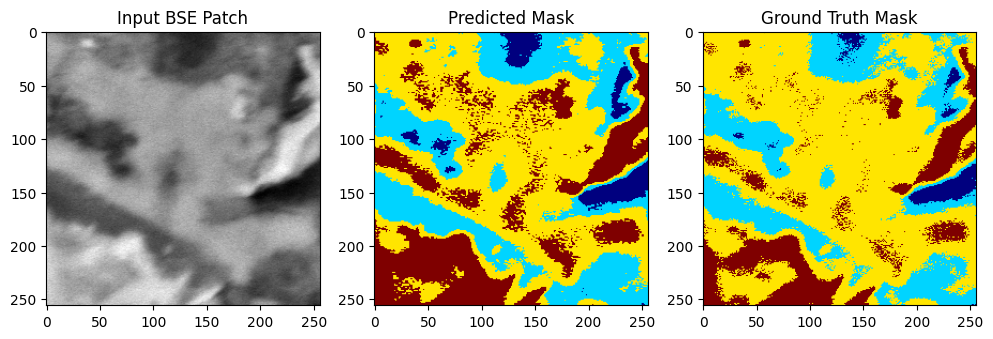

In [17]:
model.eval()
with torch.no_grad():
    images, masks = next(iter(loader))
    images = images.to(device)
    masks = masks.to(device)
    outputs = model(images)
    preds = outputs.argmax(dim=1)

    # 可视化第一张 patch
    fig, axs = plt.subplots(1,3,figsize=(12,4))
    axs[0].imshow(images[0,0].cpu(), cmap='gray')
    axs[0].set_title('Input BSE Patch')
    axs[1].imshow(preds[0].cpu(), cmap='jet', vmin=0, vmax=num_classes-1)
    axs[1].set_title('Predicted Mask')
    axs[2].imshow(masks[0].cpu(), cmap='jet', vmin=0, vmax=num_classes-1)
    axs[2].set_title('Ground Truth Mask')
    plt.show()

In [18]:
for idx in range(images.size(0)):
    print(f"--- Patch {idx} ---")
    total_pix = preds[idx].numel()
    for c in range(num_classes):
        c_pix = (preds[idx]==c).sum().item()
        print(f"Class {c}: {c_pix} pixels, {c_pix/total_pix*100:.2f}%")
    print("Ground truth distribution:")
    for c in range(num_classes):
        c_pix = (masks[idx]==c).sum().item()
        print(f"Class {c}: {c_pix} pixels, {c_pix/total_pix*100:.2f}%")

--- Patch 0 ---
Class 0: 3082 pixels, 4.70%
Class 1: 16923 pixels, 25.82%
Class 2: 30168 pixels, 46.03%
Class 3: 15363 pixels, 23.44%
Ground truth distribution:
Class 0: 1775 pixels, 2.71%
Class 1: 14380 pixels, 21.94%
Class 2: 39741 pixels, 60.64%
Class 3: 9640 pixels, 14.71%
--- Patch 1 ---
Class 0: 5418 pixels, 8.27%
Class 1: 39870 pixels, 60.84%
Class 2: 19897 pixels, 30.36%
Class 3: 351 pixels, 0.54%
Ground truth distribution:
Class 0: 3349 pixels, 5.11%
Class 1: 33389 pixels, 50.95%
Class 2: 28519 pixels, 43.52%
Class 3: 279 pixels, 0.43%
--- Patch 2 ---
Class 0: 7624 pixels, 11.63%
Class 1: 29087 pixels, 44.38%
Class 2: 25851 pixels, 39.45%
Class 3: 2974 pixels, 4.54%
Ground truth distribution:
Class 0: 6736 pixels, 10.28%
Class 1: 27163 pixels, 41.45%
Class 2: 29184 pixels, 44.53%
Class 3: 2453 pixels, 3.74%
--- Patch 3 ---
Class 0: 10255 pixels, 15.65%
Class 1: 27882 pixels, 42.54%
Class 2: 20163 pixels, 30.77%
Class 3: 7236 pixels, 11.04%
Ground truth distribution:
Class 0: 6

In [19]:
import os
import cv2
import torch
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"

# ===============================
# 1️⃣ 测试图像路径
test_image_dir = "/content/drive/MyDrive/BSE_CNN/dataset/test/img/"
test_mask_dir = "/content/drive/MyDrive/BSE_CNN/dataset/test/mask/"

test_image_files = sorted([
    f for f in os.listdir(test_image_dir)
    if f.endswith(".tif")
])


In [20]:
def predict_bse(model, image_path, patch_size=256):
    """
    Patch-based 推理 + padding + 边缘处理
    """
    model.eval()

    # 读取灰度图
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    h, w = image.shape

    # Step 1: padding 到 patch_size 的整数倍
    pad_h = (patch_size - h % patch_size) % patch_size
    pad_w = (patch_size - w % patch_size) % patch_size
    image_padded = np.pad(image, ((0, pad_h), (0, pad_w)), mode='reflect')
    H, W = image_padded.shape

    # Step 2: 初始化预测 mask
    pred_mask_padded = torch.zeros((H, W), dtype=torch.long)

    # Step 3: patch-based 推理（保证右下角也覆盖）
    stride = patch_size
    y_max = H - patch_size if H > patch_size else 0
    x_max = W - patch_size if W > patch_size else 0

    y_positions = list(range(0, H - patch_size + 1, stride))
    x_positions = list(range(0, W - patch_size + 1, stride))

    # 确保右边和底部边缘被覆盖
    if y_max not in y_positions:
        y_positions.append(y_max)
    if x_max not in x_positions:
        x_positions.append(x_max)

    with torch.no_grad():
        for y in y_positions:
            for x in x_positions:
                patch = image_padded[y:y+patch_size, x:x+patch_size]
                patch_tensor = torch.tensor(patch, dtype=torch.float32).unsqueeze(0).unsqueeze(0)/255.0
                patch_tensor = patch_tensor.to(device)
                output = model(patch_tensor)
                pred = output.argmax(dim=1).squeeze(0).cpu()
                pred_mask_padded[y:y+patch_size, x:x+patch_size] = pred

    # Step 4: 裁回原始尺寸
    pred_mask = pred_mask_padded[:h, :w]
    return pred_mask


In [21]:
def visualize_prediction(image_path, pred_mask, mask_path=None):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)
    fig, axs = plt.subplots(1,3 if mask_path else 2, figsize=(12,4))
    axs[0].imshow(image, cmap='gray')
    axs[0].set_title('Input BSE Image')

    axs[1].imshow(pred_mask, cmap='jet', vmin=0, vmax=3)
    axs[1].set_title('Predicted Mask')

    if mask_path:
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        axs[2].imshow(mask, cmap='jet', vmin=0, vmax=3)
        axs[2].set_title('Ground Truth Mask')

    plt.show()


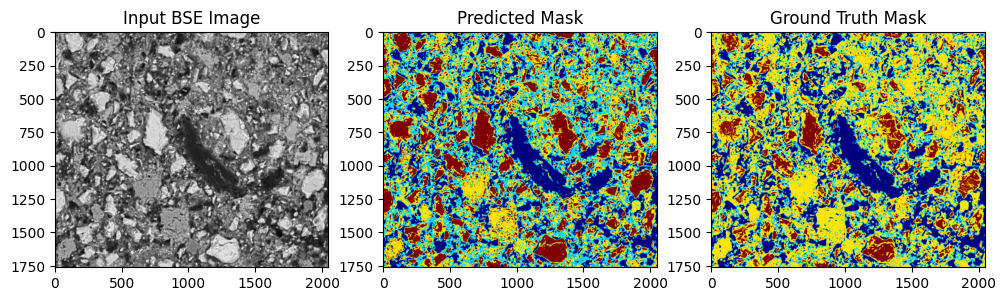

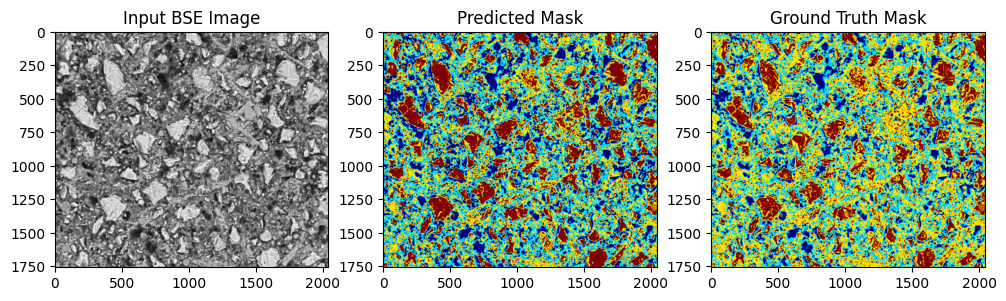

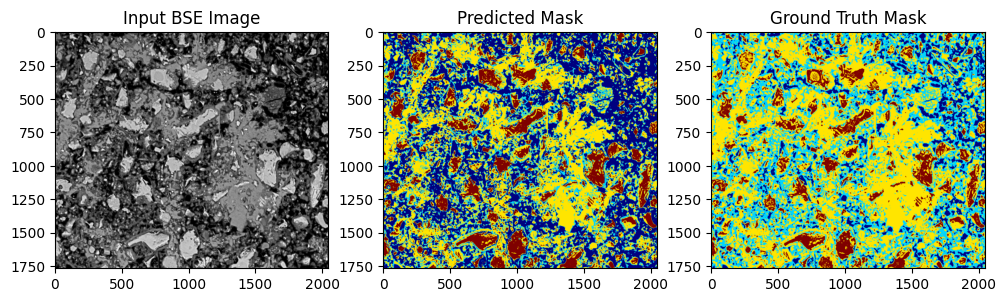

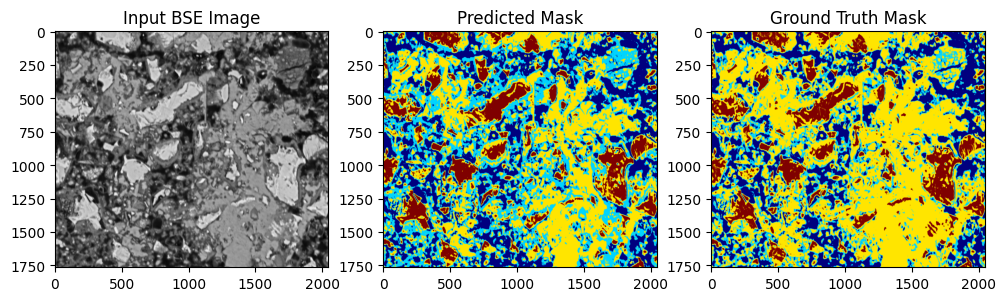

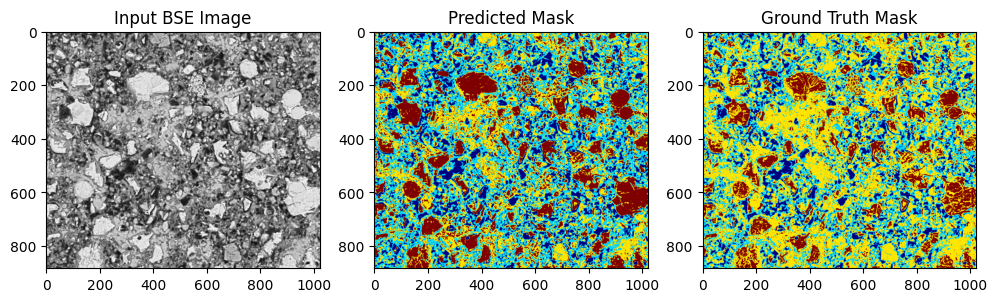

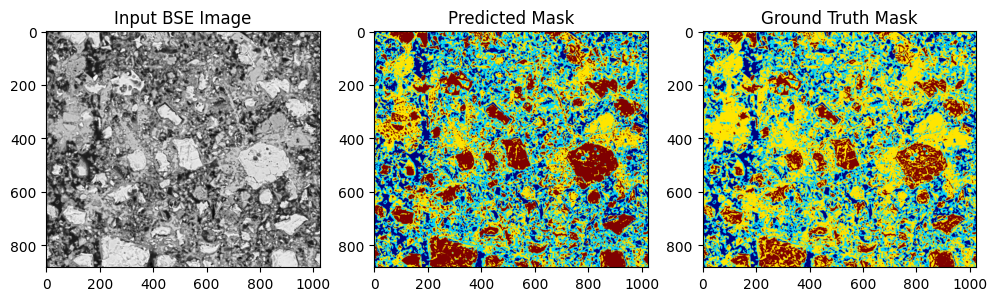

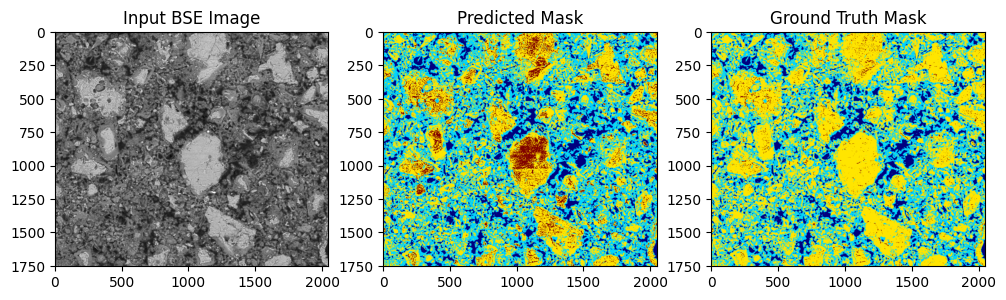

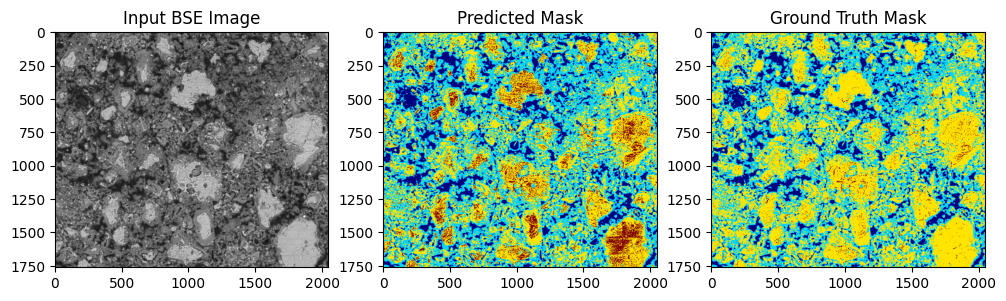

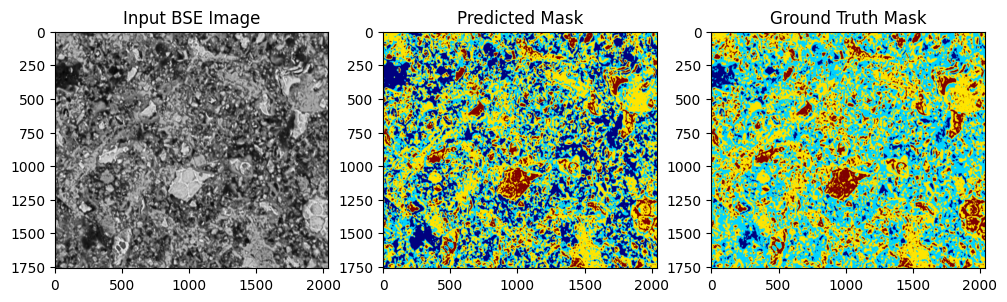

In [22]:
for img_file in test_image_files:
    img_path = os.path.join(test_image_dir, img_file)
    mask_path = os.path.join(test_mask_dir, img_file.replace(".tif","_mask.tif"))
    pred_mask = predict_bse(model, img_path, patch_size=256)

    if os.path.exists(mask_path):
        visualize_prediction(img_path, pred_mask, mask_path)
    else:
        visualize_prediction(img_path, pred_mask)

In [23]:
import os
import cv2
import torch

# 测试图像和 mask 的目录
test_image_dir = "/content/drive/MyDrive/BSE_CNN/dataset/test/img/"
test_mask_dir = "/content/drive/MyDrive/BSE_CNN/dataset/test/mask/"

# 获取所有测试图像文件
test_image_files = sorted([
    f for f in os.listdir(test_image_dir) if f.endswith(".tif")
])

# --- Accuracy 函数 ---
def pixel_accuracy(pred_mask, gt_mask):
    correct = (pred_mask == gt_mask).sum().item()
    total = gt_mask.numel()
    return correct / total

def class_accuracy(pred_mask, gt_mask, num_classes=4):
    acc_dict = {}
    for cls in range(num_classes):
        cls_total = (gt_mask == cls).sum().item()
        if cls_total == 0:
            acc_dict[cls] = None  # 数据集中没这个类别
        else:
            cls_correct = ((pred_mask == cls) & (gt_mask == cls)).sum().item()
            acc_dict[cls] = cls_correct / cls_total
    return acc_dict

# --- 批量测试 ---
pixel_acc_list = []
for img_file in test_image_files:
    img_path  = os.path.join(test_image_dir, img_file)
    mask_path = os.path.join(test_mask_dir, img_file.replace(".tif","_mask.tif"))

    # 预测
    pred_mask = predict_bse(model, img_path, patch_size=256)

    # 读取 ground truth
    gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
    gt_mask = torch.tensor(gt_mask, dtype=torch.long)

    # 整图 pixel accuracy
    acc = pixel_accuracy(pred_mask, gt_mask)
    pixel_acc_list.append(acc)
    print(f"{img_file}: Pixel Accuracy = {acc*100:.2f}%")

    # 每类 accuracy
    acc_cls = class_accuracy(pred_mask, gt_mask)
    for cls, a in acc_cls.items():
        if a is not None:
            print(f"    Class {cls} accuracy: {a*100:.2f}%")
        else:
            print(f"    Class {cls} not present in GT")

# --- 平均 Accuracy ---
mean_acc = sum(pixel_acc_list) / len(pixel_acc_list)
print(f"\nMean Pixel Accuracy over {len(test_image_files)} images: {mean_acc*100:.2f}%")


0.35_14d_001.tif: Pixel Accuracy = 82.82%
    Class 0 accuracy: 91.11%
    Class 1 accuracy: 97.04%
    Class 2 accuracy: 66.39%
    Class 3 accuracy: 99.98%
0.35_14d_002.tif: Pixel Accuracy = 82.38%
    Class 0 accuracy: 99.98%
    Class 1 accuracy: 80.60%
    Class 2 accuracy: 71.69%
    Class 3 accuracy: 97.21%
0.5_14d_001.tif: Pixel Accuracy = 63.78%
    Class 0 accuracy: 100.00%
    Class 1 accuracy: 27.62%
    Class 2 accuracy: 74.57%
    Class 3 accuracy: 99.19%
0.5_14d_002.tif: Pixel Accuracy = 79.86%
    Class 0 accuracy: 98.38%
    Class 1 accuracy: 82.99%
    Class 2 accuracy: 68.52%
    Class 3 accuracy: 88.86%
0.5_28d_001.tif: Pixel Accuracy = 80.99%
    Class 0 accuracy: 99.27%
    Class 1 accuracy: 89.47%
    Class 2 accuracy: 64.62%
    Class 3 accuracy: 99.69%
0.5_28d_002.tif: Pixel Accuracy = 85.92%
    Class 0 accuracy: 99.15%
    Class 1 accuracy: 91.35%
    Class 2 accuracy: 73.99%
    Class 3 accuracy: 99.86%
0.5_60d_001.tif: Pixel Accuracy = 86.69%
    Class 0 ac

In [1]:
# --- 计算每类 Precision / Recall / IoU ---
def class_metrics(pred_mask, gt_mask, num_classes=4):
    metrics = {}

    for cls in range(num_classes):
        TP = ((pred_mask == cls) & (gt_mask == cls)).sum().item()
        FP = ((pred_mask == cls) & (gt_mask != cls)).sum().item()
        FN = ((pred_mask != cls) & (gt_mask == cls)).sum().item()

        precision = TP / (TP + FP) if (TP + FP) > 0 else None
        recall    = TP / (TP + FN) if (TP + FN) > 0 else None
        iou       = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else None

        metrics[cls] = {
            "precision": precision,
            "recall": recall,
            "iou": iou
        }

    return metrics